## Model 2: Hierarchical table model (Stan)

**Idea:** same covariates as Model 1, but team **skill varies by season** and is measured **in points** (`tau_skill`).

**Backtest:** tables through 2024/25 → predict table 2025/26.

$$\text{Pts}_{s,t} \sim t_{\nu}\big(\alpha + \text{skill}_{s,t} + \gamma^\top x_{s,t},\; \sigma_{\mathrm{pts}}\big)$$

with $x$ = (`sot_diff_pg`, `pts_lag1`, `ppg_last10`, z-scored) and $\sum_t \text{skill}_{s,t}=0$ per season.
Student-$t$ with $\nu=5$ fixed; $\tau_{\mathrm{skill}}$ — typical spread of team strengths in **points**.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_hierarchical,
    build_forecast_features,
    compute_table,
    predict_table,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [12]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
LAST_TRAIN_SEASON = "2425"

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, season_to_idx, feature_stats = (
    prepare_table_stan_hierarchical(tables, TRAIN_SEASONS)
)
stan_data["nu"] = STUDENT_T_NU
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[LAST_TRAIN_SEASON]

print(f"Rows: {stan_data['N']}, seasons S={stan_data['S']}, teams T={stan_data['T']}")
print(f"Forecast uses season {LAST_TRAIN_SEASON} (index {last_season_idx})")
print(tables[['sot_diff_pg', 'pts_lag1', 'ppg_last10']].describe().round(2))


Rows: 320, seasons S=16, teams T=42
Forecast uses season 2425 (index 16)
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.00     45.02        1.39
std           1.98     26.80        0.59
min          -4.66      0.00        0.00
25%          -1.38     38.00        0.90
50%          -0.39     47.00        1.40
75%           1.24     63.25        1.80
max           6.03    100.00        3.00


### Prior selection (Model 2)

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `intercept`, `beta_*`, `sigma_pts` | as Model 1 | Same likelihood (Student-$t$, $\nu=5$) |
| `tau_skill` | $\mathcal{N}(12, 5)$ | Team spread **in points** within a season (~12 pts SD) |

**Reparameterization:** `skill[season, team]` is directly on the points scale (no `beta_pts` × `sigma_skill` product), which fixes non-identifiability and improves sampling of $\sigma_{\mathrm{pts}}$ and skills.


In [13]:
model = CmdStanModel(stan_file="stan/table_hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


16:10:12 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:10:23 - cmdstanpy - INFO - CmdStan done processing.
16:10:23 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
	Exception: student_t_lpdf: Location parameter is nan, but must be finite! (in 'table_hierarchical.stan', line 53, column 4 to column 42)
Exception: student_t_lp


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  log_sigma_pts, log_tau_skill, sigma_pts, tau_skill
Such high values indicate incomplete mixing and biased estimation.
You should consider regularizating your model with additional prior information or a more effective parameterization.

Processing complete.



### Sampling diagnostics

Check divergences (`fit.diagnose()` above), $\hat{R}$, and ESS.
Target: $\hat{R} \leq 1.01$, ESS bulk $\gtrsim 400$ per parameter.


                 Mean      MCSE     StdDev        MAD           5%  \
intercept    52.30560  0.005893   0.376125   0.379027    51.687800   
beta_sot      9.28099  0.012826   0.641633   0.649231     8.222980   
beta_lag      1.25978  0.005503   0.355371   0.352540     0.678357   
beta_form     7.14472  0.012874   0.632611   0.635969     6.101690   
sigma_pts     4.22662  0.024589   0.532795   0.541512     3.362890   
tau_skill     5.88786  0.024893   0.577937   0.569066     4.905650   
lp__      -1001.26000  2.043640  41.279000  41.059100 -1064.640000   

                  50%        95%  ESS_bulk  ESS_tail    R_hat  
intercept    52.29650   52.92280  4100.240  4377.160  1.00044  
beta_sot      9.27651   10.32660  2505.130  3579.920  1.00086  
beta_lag      1.25867    1.84444  4160.170  4650.220  1.00017  
beta_form     7.15050    8.19250  2432.130  3421.290  1.00062  
sigma_pts     4.22212    5.11021   479.405   900.725  1.02024  
tau_skill     5.90871    6.81011   554.655  1158.360  1

,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
intercept,52.306,0.376,51.588,52.985,4100.0,4377.0,1.00
beta_sot,9.281,0.642,8.048,10.435,2505.0,3580.0,1.00
beta_lag,1.260,0.355,0.616,1.950,4160.0,4650.0,1.00
beta_form,7.145,0.633,5.962,8.323,2432.0,3421.0,1.00
sigma_pts,4.227,0.533,3.223,5.206,479.0,901.0,1.02
tau_skill,5.888,0.578,4.785,6.949,555.0,1158.0,1.02


Parameters with R-hat > 1.01: 2


,mean,sd,hdi_3%,hdi_97%,ess_bulk,ess_tail,r_hat
sigma_pts,4.227,0.533,3.223,5.206,479.0,901.0,1.02
tau_skill,5.888,0.578,4.785,6.949,555.0,1158.0,1.02


Parameters with ESS_bulk < 400: 0


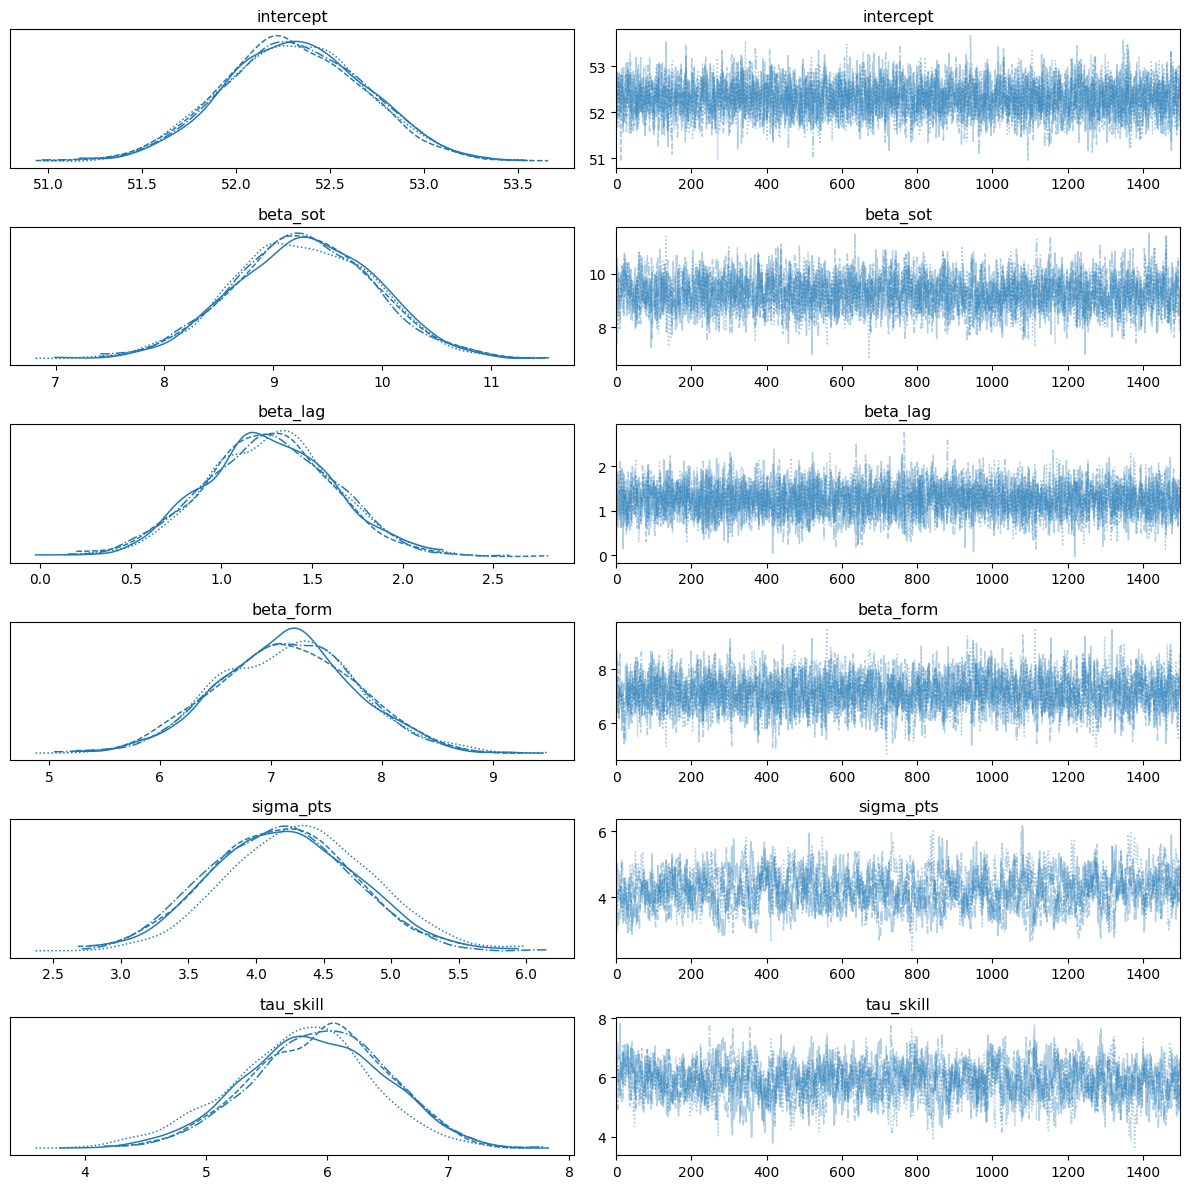

In [15]:
param_vars = [
    "intercept", "beta_sot", "beta_lag", "beta_form",
    "sigma_pts", "tau_skill",
]
print(fit.summary().loc[param_vars + ["lp__"]])

idata = az.from_cmdstanpy(fit)
diag = az.summary(idata, var_names=param_vars)
cols = ["mean", "sd", "hdi_3%", "hdi_97%", "ess_bulk", "ess_tail", "r_hat"]
display(diag[cols])

bad_rhat = diag[diag["r_hat"] > 1.01]
low_ess = diag[diag["ess_bulk"] < 400]
print(f"Parameters with R-hat > 1.01: {len(bad_rhat)}")
if len(bad_rhat):
    display(bad_rhat[cols])
print(f"Parameters with ESS_bulk < 400: {len(low_ess)}")
if len(low_ess):
    display(low_ess[cols])

az.plot_trace(idata, var_names=param_vars, compact=True)
plt.tight_layout()
plt.show()


In [16]:
s_idx = last_season_idx - 1
skill_last = fit.stan_variable("skill")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

pd.DataFrame({
    "team": [idx_to_team[j+1] for j in range(len(skill_last))],
    "skill": skill_last,
}).sort_values("skill", ascending=False).head(10)


,team,skill
20,Liverpool,8.319278
27,Nott'm Forest,7.989489
25,Newcastle,3.637947
0,Arsenal,3.100099
14,Fulham,1.666365
6,Bournemouth,1.537150
7,Brentford,1.387387
8,Brighton,1.301952
11,Chelsea,0.646909
10,Cardiff,0.258156


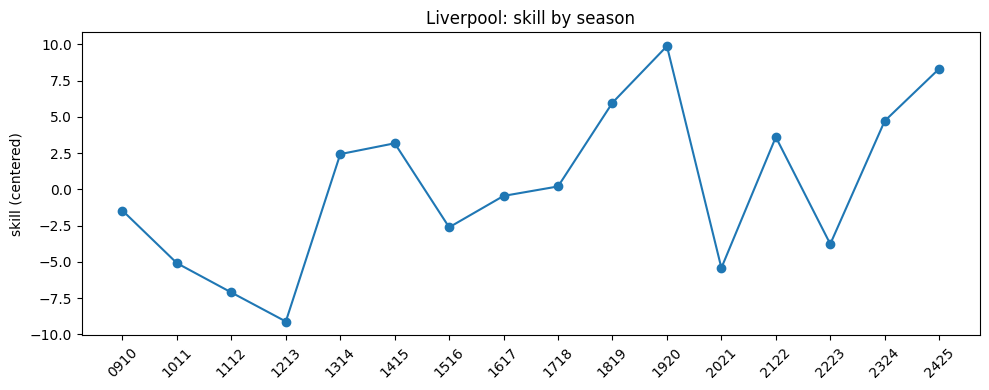

In [17]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    skill_ts = fit.stan_variable("skill")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, skill_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("skill (centered)")
    plt.title(f"{example_team}: skill by season")
    plt.tight_layout()
    plt.show()


### Posterior predictive check (PPC)

Simulate **replicated team-season points** from the posterior (Student-$t$ likelihood).
Compare the distribution and simple test statistics (mean, SD, min, max) to observed training points.
$p \approx 0.5$ suggests good calibration; values near 0 or 1 flag misfit.


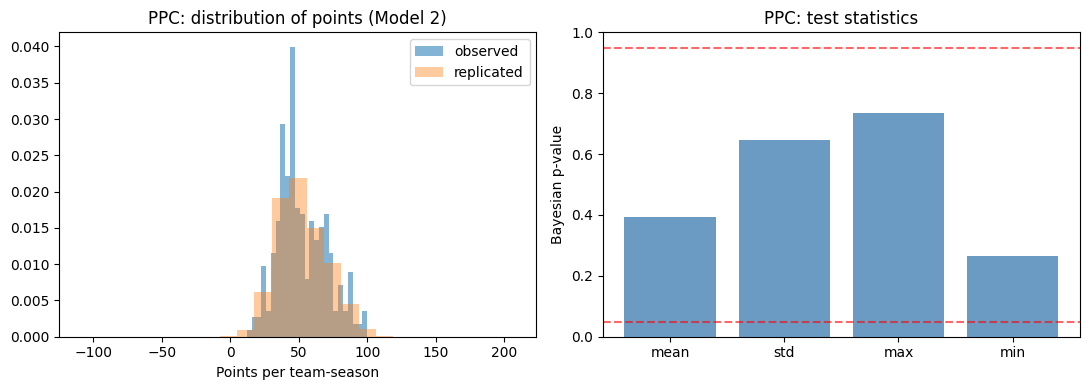

  mean: p = 0.394
  std: p = 0.646
  max: p = 0.735
  min: p = 0.264


In [18]:
from helping_functions import ppc_table_replicates

y_obs = stan_data["pts"]
y_rep = ppc_table_replicates(fit, stan_data, model="hierarchical")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(y_obs, bins=25, density=True, alpha=0.55, label="observed")
axes[0].hist(y_rep.reshape(-1), bins=25, density=True, alpha=0.4, label="replicated")
axes[0].set_xlabel("Points per team-season")
axes[0].set_title("PPC: distribution of points (Model 2)")
axes[0].legend()

stats = {"mean": np.mean, "std": np.std, "max": np.max, "min": np.min}
pvals = {}
for name, fn in stats.items():
    obs_val = fn(y_obs)
    rep_vals = fn(y_rep, axis=1)
    pvals[name] = float((rep_vals >= obs_val).mean())

axes[1].bar(pvals.keys(), pvals.values(), color="steelblue", alpha=0.8)
axes[1].axhline(0.05, color="red", ls="--", alpha=0.6)
axes[1].axhline(0.95, color="red", ls="--", alpha=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Bayesian p-value")
axes[1].set_title("PPC: test statistics")
plt.tight_layout()
plt.show()

for name, p in pvals.items():
    print(f"  {name}: p = {p:.3f}")


**PPC interpretation (Model 2):** same logic as Model 1. If replicated points are too narrow/wide vs. observed, $\sigma_{\mathrm{skill}}$ or $\sigma_{\mathrm{pts}}$ may be mis-specified.


### Predict table 2025/26


In [19]:
forecast_features = build_forecast_features(
    matches, LAST_TRAIN_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

pred_table = predict_table(
    fit,
    test_teams,
    team_to_idx,
    model="hierarchical",
    last_season_index=last_season_idx,
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)

actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_table.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
1,Arsenal,3.0,3.624,71.342828,71.415565,1,85,2.0
2,Man City,3.0,3.012,73.245789,73.479539,2,78,1.0
17,Man United,17.0,16.708,44.531323,44.430843,3,71,14.0
4,Aston Villa,5.0,5.598,66.649675,66.438975,4,65,1.0
0,Liverpool,1.0,2.098,77.861227,77.506809,5,60,-4.0
8,Bournemouth,11.0,11.110,55.282802,55.378615,6,57,5.0
11,Sunderland,13.0,12.680,52.811586,52.602998,7,54,6.0
6,Brighton,8.0,8.410,60.714208,60.423559,8,53,0.0
9,Brentford,11.0,11.244,55.456775,55.186394,9,53,2.0
3,Chelsea,4.0,4.768,68.339669,68.511782,10,52,-6.0


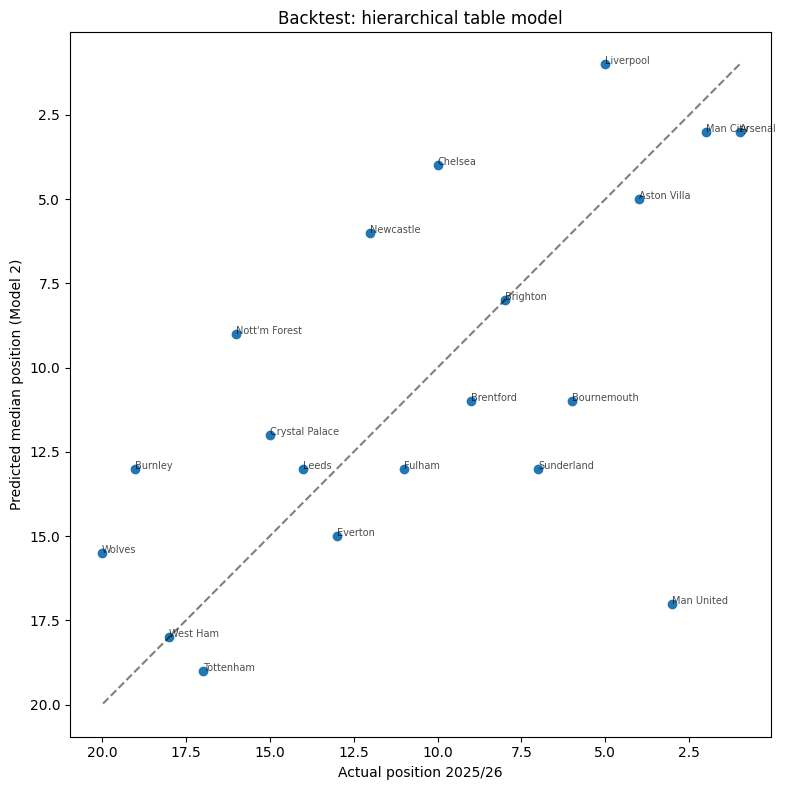

MAE position: 3.73


In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position (Model 2)")
ax.set_title("Backtest: hierarchical table model")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f"MAE position: {comparison['pos_error'].abs().mean():.2f}")


### WAIC / LOO

Student-$t$ likelihood should lower Pareto $k$ for outlier team-seasons vs. Normal.  
Check `pareto_k`: values $\leq 0.7$ are reliable; $> 0.7$ = influential points.


In [21]:
idata = az.from_cmdstanpy(fit)
print(az.waic(idata))
loo = az.loo(idata, pointwise=True)
print(loo)

k = loo.pareto_k.values
n_good = int((k <= 0.7).sum())
n_bad = int(((k > 0.7) & (k <= 1)).sum())
n_very_bad = int((k > 1).sum())
print(f"\nPareto k: good (≤0.7) {n_good}/{len(k)} ({100 * n_good / len(k):.1f}%)")
print(f"           bad (0.7–1] {n_bad}, very bad (>1) {n_very_bad}")


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -1078.46    12.34
p_waic      174.89        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Computed from 6000 posterior samples and 320 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1098.26    11.85
p_loo      194.69        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      313   97.8%
   (0.70, 1]   (bad)         7    2.2%
   (1, Inf)   (very bad)    0    0.0%


Pareto k: good (≤0.7) 313/320 (97.8%)
           bad (0.7–1] 7, very bad (>1) 0


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
